In [1]:
%%capture
!pip install timm huggingface_hub scanpy anndata scipy scikit-learn h5py
print('Done.')

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
import scanpy as sc
from huggingface_hub import login, hf_hub_download
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from PIL import Image
import h5py
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [3]:
# Paste your HuggingFace token here (must have access to MahmoodLab/UNI and MahmoodLab/hest)
HF_TOKEN = "pls put in your api key"
login(token=HF_TOKEN)
print('Logged in.')

Logged in.


In [4]:
# Load UNI directly via timm (official method from model card)
# Downloads weights automatically to ~/.cache/huggingface/hub/
uni_encoder = timm.create_model(
    "hf-hub:MahmoodLab/uni",
    pretrained=True,
    init_values=1e-5,
    dynamic_img_size=True
)

# Get official UNI image transforms
UNI_TRANSFORM = create_transform(
    **resolve_data_config(uni_encoder.pretrained_cfg, model=uni_encoder)
)

# Freeze ALL UNI parameters — never updated during training
# Reason: 307M params, only 66k training spots — fine-tuning would overfit severely
for param in uni_encoder.parameters():
    param.requires_grad = False

uni_encoder = uni_encoder.eval().to(DEVICE)

print('UNI loaded and frozen.')
print(f'Output embedding dim: 1024')
print(f'Trainable params in UNI: {sum(p.numel() for p in uni_encoder.parameters() if p.requires_grad):,}')
print(f'Total UNI params (frozen): {sum(p.numel() for p in uni_encoder.parameters()):,}')

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

UNI loaded and frozen.
Output embedding dim: 1024
Trainable params in UNI: 0
Total UNI params (frozen): 303,350,784


In [5]:
CANCER_TO_ORGAN = {
    'COAD': 0,     # GI
    'READ': 0,     # GI
    'STAD': 0,     # GI
    'IDC':  1,     # Breast
    'ILC':  1,     # Breast
    'EPM':  2,     # Brain/CNS
    'GBM':  2,     # Brain/CNS
    'LIHB': 3,     # Liver/Biliary
    'CHOL': 3,     # Liver/Biliary
    'SCCRCC': 4,   # Urological
    'PRAD': 4,     # Urological
    'BLCA': 4,     # Urological
}
ORGAN_NAMES    = ['GI', 'Breast', 'Brain/CNS', 'Liver', 'Urological', 'Other']
N_ORGAN_GROUPS = 6
N_CANCER_TYPES = 29    # total in HEST-1k
N_GENES        = 50    # HEST-Benchmark standard: top-50 HVGs per task

CANCER_TYPES  = sorted(CANCER_TO_ORGAN.keys())
CANCER_TO_IDX = {c: i for i, c in enumerate(CANCER_TYPES)}

print('Cancer type -> organ group:')
for cancer, organ_idx in CANCER_TO_ORGAN.items():
    print(f'  {cancer:10s} -> {ORGAN_NAMES[organ_idx]}')

Cancer type -> organ group:
  COAD       -> GI
  READ       -> GI
  STAD       -> GI
  IDC        -> Breast
  ILC        -> Breast
  EPM        -> Brain/CNS
  GBM        -> Brain/CNS
  LIHB       -> Liver
  CHOL       -> Liver
  SCCRCC     -> Urological
  PRAD       -> Urological
  BLCA       -> Urological


In [6]:
import anndata as ad
def load_multi_cancer(cancer_types, n_genes=50, max_samples=2):
    """
    Load patches and expression across multiple cancer types.
    Computes shared HVGs across all samples combined so every
    cancer type predicts the same 50 genes.
    """
    all_patches    = []
    all_expression = []
    all_cancer_idx = []
    all_adatas     = []

    # First pass: load all expression data to compute shared HVGs
    print('Pass 1: loading expression data...')
    sample_info = []  # store (patches_path, adata, cancer_type) for second pass

    for ct in cancer_types:
        print(f'\n  Cancer type: {ct}')
        meta = pd.read_csv('hf://datasets/MahmoodLab/hest/HEST_v1_3_0.csv')
        samples = meta[
            (meta['oncotree_code'] == ct) &
            (meta['st_technology'] == 'Visium') &
            (meta['species'] == 'Homo sapiens')
        ]['id'].tolist()[:max_samples]

        for sample_id in samples:
            print(f'    Loading {sample_id}...')
            try:
                st_path = hf_hub_download(
                    repo_id='MahmoodLab/hest',
                    filename=f'st/{sample_id}.h5ad',
                    repo_type='dataset'
                )
                patch_path = hf_hub_download(
                    repo_id='MahmoodLab/hest',
                    filename=f'patches/{sample_id}.h5',
                    repo_type='dataset'
                )
                adata = sc.read_h5ad(st_path)
                adata.var_names_make_unique()
                adata.obs_names_make_unique()
                sc.pp.filter_cells(adata, min_genes=50)
                sc.pp.normalize_total(adata, target_sum=1e4)
                sc.pp.log1p(adata)
                sample_info.append((patch_path, adata, ct))
                all_adatas.append(adata)
            except Exception as e:
                print(f'    Skipping {sample_id}: {e}')

    # Compute shared HVGs on combined expression matrix
    print('\nComputing shared HVGs across all cancer types...')
    combined = ad.concat(all_adatas, join='inner')  # inner join = shared genes only
    sc.pp.highly_variable_genes(combined, n_top_genes=n_genes, flavor='cell_ranger')
    shared_hvgs = combined.var_names[combined.var['highly_variable']].tolist()[:n_genes]
    print(f'Shared HVG set: {len(shared_hvgs)} genes')

    # Second pass: extract patches + expression using shared HVGs
    print('\nPass 2: aligning patches and expression...')
    for patch_path, adata, ct in sample_info:
        # Get expression for shared HVGs only
        common_genes = [g for g in shared_hvgs if g in adata.var_names]
        if len(common_genes) < n_genes // 2:
            print(f'  Too few shared genes for a sample in {ct}, skipping')
            continue

        expr = adata[:, common_genes].X
        if hasattr(expr, 'toarray'):
            expr = expr.toarray()
        expr = np.array(expr, dtype=np.float32)

        # Pad to n_genes if some genes missing
        if expr.shape[1] < n_genes:
            pad = np.zeros((expr.shape[0], n_genes - expr.shape[1]), dtype=np.float32)
            expr = np.concatenate([expr, pad], axis=1)

        # Load and align patches
        with h5py.File(patch_path, 'r') as f:
            patches  = f['img'][:]
            barcodes = f['barcode'][:]

        patch_bc_map = {}
        for i, b in enumerate(barcodes):
            if isinstance(b, np.ndarray):
                key = b[0].decode() if isinstance(b[0], bytes) else str(b[0])
            elif isinstance(b, bytes):
                key = b.decode()
            else:
                key = str(b)
            patch_bc_map[key] = i

        expr_barcodes = [str(bc) for bc in adata.obs_names.tolist()]
        matched_p, matched_e = [], []
        for ei, bc in enumerate(expr_barcodes):
            if bc in patch_bc_map:
                matched_p.append(patch_bc_map[bc])
                matched_e.append(ei)

        if not matched_p:
            continue

        all_patches.append(patches[matched_p])
        all_expression.append(expr[matched_e])
        all_cancer_idx.extend([CANCER_TO_IDX.get(ct, 0)] * len(matched_p))
        print(f'  {ct}: loaded {len(matched_p)} spots')

    patches    = np.concatenate(all_patches,    axis=0)
    expression = np.concatenate(all_expression, axis=0)
    cancer_idx = np.array(all_cancer_idx, dtype=np.int64)

    print(f'\nTotal: {len(patches)} spots across {len(cancer_types)} cancer types')
    print(f'Cancer type distribution:')
    for ct in cancer_types:
        idx = CANCER_TO_IDX.get(ct, 0)
        count = (cancer_idx == idx).sum()
        print(f'  {ct}: {count} spots')

    return patches, expression, cancer_idx, shared_hvgs


# Load 4 cancer types, 1 samples each
CANCER_TYPES_MULTI = ['COAD', 'IDC', 'SCCRCC', 'EPM']
patches_all, expr_all, cancer_idx_all, shared_hvgs = load_multi_cancer(
    CANCER_TYPES_MULTI, n_genes=N_GENES, max_samples=2
)

Pass 1: loading expression data...

  Cancer type: COAD
    Loading TENX152...


st/TENX152.h5ad:   0%|          | 0.00/352M [00:00<?, ?B/s]

patches/TENX152.h5:   0%|          | 0.00/634M [00:00<?, ?B/s]

    Loading MISC73...


st/MISC73.h5ad:   0%|          | 0.00/151M [00:00<?, ?B/s]

...

patches/NCBI641.h5:   0%|          | 0.00/346M [00:00<?, ?B/s]

    Loading NCBI640...


st/NCBI640.h5ad:   0%|          | 0.00/68.1M [00:00<?, ?B/s]

patches/NCBI640.h5:   0%|          | 0.00/302M [00:00<?, ?B/s]


Computing shared HVGs across all cancer types...
Shared HVG set: 50 genes

Pass 2: aligning patches and expression...
  COAD: loaded 4096 spots
  COAD: loaded 3885 spots
  IDC: loaded 1624 spots
  IDC: loaded 4834 spots
  SCCRCC: loaded 4479 spots
  SCCRCC: loaded 4755 spots
  EPM: loaded 2233 spots
  EPM: loaded 1953 spots

Total: 27859 spots across 4 cancer types
Cancer type distribution:
  COAD: 7981 spots
  IDC: 6458 spots
  SCCRCC: 9234 spots
  EPM: 4186 spots


In [7]:
import os

def preextract_and_save_embeddings(patches, uni_encoder, transform,
                                    save_path='embeddings_cache.pt',
                                    batch_size=128):
    """
    Run UNI once on all patches and save to disk.
    Next time the session restarts, just load from disk — no recomputation.
    """
    # If cache exists, load it directly
    if os.path.exists(save_path):
        print(f'Loading cached embeddings from {save_path}...')
        embeddings = torch.load(save_path, map_location='cpu')
        print(f'Loaded. Shape: {embeddings.shape}')
        return embeddings

    # Otherwise extract and save
    print(f'Extracting UNI embeddings (runs once)...')
    uni_encoder.eval()
    all_embeddings = []
    n = len(patches)

    for start in range(0, n, batch_size):
        batch = patches[start:start+batch_size]
        imgs  = torch.stack([
            transform(Image.fromarray(p.astype(np.uint8)))
            for p in batch
        ]).to(DEVICE)

        with torch.no_grad():
            emb = uni_encoder(imgs)
        all_embeddings.append(emb.cpu())
        print(f'  {min(start+batch_size, n)}/{n}', end='\r')

    embeddings = torch.cat(all_embeddings, dim=0)
    torch.save(embeddings, save_path)
    print(f'\nDone. Shape: {embeddings.shape}')
    print(f'Saved to {save_path} — will be loaded directly next session')
    return embeddings


# Extract and cache — if cache exists this just loads in seconds
all_embeddings = preextract_and_save_embeddings(
    patches_all,
    uni_encoder,
    UNI_TRANSFORM,
    save_path='embeddings_cache.pt'
)

Extracting UNI embeddings (runs once)...

Done. Shape: torch.Size([27859, 1024])
Saved to embeddings_cache.pt — will be loaded directly next session


In [8]:
class HESTDataset(Dataset):
    def __init__(self, embeddings, expression, cancer_idx):
        self.embeddings = embeddings
        self.expression = torch.tensor(expression, dtype=torch.float32)
        self.cancer_idx = torch.tensor(cancer_idx, dtype=torch.long)

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return {
            'patch':      self.embeddings[idx],   # 1024-dim, UNI already ran
            'cancer_idx': self.cancer_idx[idx],
            'expression': self.expression[idx]
        }


# Patient-level split — first half of each cancer type's spots -> train
# second half (different patient) -> val/test
train_mask = np.ones(len(patches_all), dtype=bool)
start = 0
for ct in CANCER_TYPES_MULTI:
    cidx  = CANCER_TO_IDX.get(ct, 0)
    count = int((cancer_idx_all == cidx).sum())
    half  = count // 2
    train_mask[start + half : start + count] = False
    start += count

idx_train = np.where(train_mask)[0]
idx_tmp   = np.where(~train_mask)[0]
idx_val, idx_test = train_test_split(idx_tmp, test_size=0.50, random_state=42)

train_ds = HESTDataset(all_embeddings[idx_train], expr_all[idx_train], cancer_idx_all[idx_train])
val_ds   = HESTDataset(all_embeddings[idx_val],   expr_all[idx_val],   cancer_idx_all[idx_val])
test_ds  = HESTDataset(all_embeddings[idx_test],  expr_all[idx_test],  cancer_idx_all[idx_test])

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_ds)} spots')
print(f'Val   : {len(val_ds)} spots')
print(f'Test  : {len(test_ds)} spots')
print()
print('Split breakdown by cancer type:')
for ct in CANCER_TYPES_MULTI:
    cidx        = CANCER_TO_IDX.get(ct, 0)
    train_count = int((cancer_idx_all[idx_train] == cidx).sum())
    val_count   = int((cancer_idx_all[idx_val]   == cidx).sum())
    test_count  = int((cancer_idx_all[idx_test]  == cidx).sum())
    print(f'  {ct:8s}: train={train_count} | val={val_count} | test={test_count}')

Train : 13929 spots
Val   : 6965 spots
Test  : 6965 spots

Split breakdown by cancer type:
  COAD    : train=3990 | val=1996 | test=1995
  IDC     : train=3229 | val=1609 | test=1620
  SCCRCC  : train=4617 | val=2305 | test=2312
  EPM     : train=2093 | val=1055 | test=1038


## Cell 8: Model Architecture

```
H&E Patch (224x224)          Cancer Type Label
      |                             |
 UNI Encoder (FROZEN)       Embedding Table
      |                             |
 1024-dim image emb          64-dim cancer emb
      |                             |
 Projection MLP                     |
 (1024->512->256)                   |
      |                             |
      +----------- concat ----------+
                       |
                  320-dim routing vector
                       |
               Gating Network
               (320->128->6, Softmax)
                       |
          6 organ-level expert weights
                       |
  [GI] [Breast] [Brain] [Liver] [Urol.] [Other]
    each: 256->256->128->50
                       |
                weighted sum
                       |
          50-dim gene expression prediction
```

In [9]:
class ProjectionMLP(nn.Module):
    """
    Compresses 1024-dim UNI embedding to 256-dim.
    Selects task-relevant features and reduces downstream param count.
    LayerNorm stabilizes gradient flow into shallow expert heads.
    """
    def __init__(self, in_dim=1024, hidden_dim=512, out_dim=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
            nn.LayerNorm(out_dim)
        )
    def forward(self, x):
        return self.net(x)   # (B, 256)


class CancerTypeEncoder(nn.Module):
    """
    Encodes cancer type as a 64-dim learned embedding.

    Only cancer type used (not organ, not platform) because:
    - Cancer type directly encodes the biological context needed for routing
    - Organ is redundant given cancer type (COAD already implies bowel)
    - Platform differences handled by upstream data normalization
    """
    def __init__(self, n_cancer_types=29, embed_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(n_cancer_types, embed_dim)

    def forward(self, cancer_idx):
        return self.embedding(cancer_idx)   # (B, 64)


class GatingNetwork(nn.Module):
    """
    Single-level softmax router: 320-dim -> 6 organ expert weights.

    Routes to organ groups (not per cancer type) because:
    - 16/29 cancer types have fewer than 5 training samples (139x imbalance)
    - Organ groups have 50-150 samples each for stable gradient estimates
    """
    def __init__(self, in_dim=320, hidden_dim=128, n_experts=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_experts)
        )

    def forward(self, routing_vec):
        logits  = self.net(routing_vec)         # (B, n_experts)
        weights = F.softmax(logits, dim=-1)     # (B, n_experts)
        return weights, logits


class ExpertMLP(nn.Module):
    """
    Single organ-specific expert MLP.

    Receives ONLY the 256-dim image embedding, not the cancer type label.
    This forces genuine image-to-expression learning rather than
    shortcutting via metadata (e.g. outputting average COAD expression).

    No output activation: log1p-normalized expression is unbounded.
    """
    def __init__(self, in_dim=256, hidden_dim=256, out_dim=50, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim)
        )

    def forward(self, x):
        return self.net(x)   # (B, 50)


class HistoMoE(nn.Module):
    def __init__(self, uni_encoder, n_cancer_types=29, n_experts=6,
                 n_genes=50, dropout=0.1):
        super().__init__()
        self.uni_encoder    = uni_encoder        # kept in model but not called during training
        self.proj_mlp       = ProjectionMLP(1024, 512, 256, dropout)
        self.cancer_encoder = CancerTypeEncoder(n_cancer_types, 64)
        self.gating         = GatingNetwork(320, 128, n_experts)
        self.experts        = nn.ModuleList([
            ExpertMLP(256, 256, n_genes, dropout) for _ in range(n_experts)
        ])
        self.n_experts = n_experts

    def forward(self, embedding, cancer_idx):
        # embedding: (B, 1024) — pre-extracted, UNI not called here
        img_emb         = self.proj_mlp(embedding)
        cancer_emb      = self.cancer_encoder(cancer_idx)
        routing_vec     = torch.cat([img_emb, cancer_emb], dim=-1)
        gate_weights, _ = self.gating(routing_vec)
        expert_outs     = torch.stack([exp(img_emb) for exp in self.experts], dim=1)
        prediction      = (gate_weights.unsqueeze(-1) * expert_outs).sum(dim=1)
        return prediction, gate_weights


class BaselineMLP(nn.Module):
    def __init__(self, uni_encoder, n_genes=50, dropout=0.1):
        super().__init__()
        self.uni_encoder = uni_encoder
        self.proj_mlp    = ProjectionMLP(1024, 512, 256, dropout)
        self.head        = ExpertMLP(256, 256, n_genes, dropout)

    def forward(self, embedding, cancer_idx=None):
        # embedding: (B, 1024) — pre-extracted
        img_emb    = self.proj_mlp(embedding)
        prediction = self.head(img_emb)
        return prediction, None


baseline_model = BaselineMLP(uni_encoder, n_genes=N_GENES).to(DEVICE)
histomoe_model = HistoMoE(uni_encoder,    n_genes=N_GENES).to(DEVICE)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Baseline trainable params : {count_trainable(baseline_model):,}')
print(f'HistoMoE trainable params : {count_trainable(histomoe_model):,}')
print(f'(UNI 307M params are frozen and not counted)')

Baseline trainable params : 762,802
HistoMoE trainable params : 1,332,210
(UNI 307M params are frozen and not counted)


In [10]:
def load_balance_loss(gate_weights):
    """
    Prevents expert collapse (all inputs routing to one expert).

    loss = N_experts * sum_i(f_i * p_i)
    f_i = fraction of batch routed to expert i (hard assignment)
    p_i = mean softmax probability for expert i (soft)

    Minimized when all experts receive equal load.
    Reference: Switch Transformer (Fedus et al., 2022)
    """
    if gate_weights is None:
        return torch.tensor(0.0)

    n_experts = gate_weights.shape[-1]
    assignments = gate_weights.argmax(dim=-1)    # (B,)
    f = torch.zeros(n_experts, device=gate_weights.device)
    for i in range(n_experts):
        f[i] = (assignments == i).float().mean()
    p = gate_weights.mean(dim=0)                 # (n_experts,)
    return n_experts * (f * p).sum()


def compute_loss(pred, target, gate_weights, lambda_bal=0.01):
    """Total loss = MSE + lambda * load_balance_loss"""
    mse = F.mse_loss(pred, target)
    bal = load_balance_loss(gate_weights)
    return mse + lambda_bal * bal, mse.item(), bal.item()


print('Loss: MSE + 0.01 * load_balance_loss')

Loss: MSE + 0.01 * load_balance_loss


In [11]:
def evaluate_pearson(model, loader, device):
    """
    Per-gene Pearson correlation between predicted and actual expression.
    Averaged across all 50 genes. This is the HEST-Benchmark standard metric.
    """
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in loader:
            patch      = batch['patch'].to(device)
            cancer_idx = batch['cancer_idx'].to(device)
            target     = batch['expression']
            pred, _    = model(patch, cancer_idx)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(target.numpy())

    preds   = np.concatenate(all_preds,   axis=0)   # (N, 50)
    targets = np.concatenate(all_targets, axis=0)   # (N, 50)

    per_gene_corr = []
    for g in range(preds.shape[1]):
        corr, _ = pearsonr(preds[:, g], targets[:, g])
        if not np.isnan(corr):
            per_gene_corr.append(corr)

    return np.mean(per_gene_corr), per_gene_corr


print('Metric: mean per-gene Pearson correlation (HEST-Benchmark standard)')

Metric: mean per-gene Pearson correlation (HEST-Benchmark standard)


In [12]:
def train_model(model, train_loader, val_loader, n_epochs=50, lr=1e-3,
                weight_decay=1e-4, patience=10, lambda_bal=0.01, name='model'):
    """
    AdamW optimizer + cosine LR decay + early stopping on val Pearson.
    """
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    best_corr, best_state, patience_count = -np.inf, None, 0
    history = []

    print(f'\nTraining {name} | trainable params: {count_trainable(model):,}')
    print('-' * 55)

    for epoch in range(n_epochs):
        model.train()
        losses = []
        print(losses)

        for batch_idx, batch in enumerate(train_loader):
            patch      = batch['patch'].to(DEVICE)
            cancer_idx = batch['cancer_idx'].to(DEVICE)
            target     = batch['expression'].to(DEVICE)

            optimizer.zero_grad()
            pred, gw    = model(patch, cancer_idx)
            loss, _, _  = compute_loss(pred, target, gw, lambda_bal)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()), 1.0)
            optimizer.step()
            losses.append(loss.item())

            # Per-step progress (overwrites same line)
            print(f'  Epoch {epoch+1}/{n_epochs} | Step {batch_idx+1}/{len(train_loader)} | Step Loss: {loss.item():.4f}', end='\r')

        scheduler.step()
        val_corr, _ = evaluate_pearson(model, val_loader, DEVICE)
        history.append({'epoch': epoch+1, 'loss': np.mean(losses), 'val_pearson': val_corr})

        # Per-epoch summary on a new line
        print(f'Epoch {epoch+1:3d}/{n_epochs} | Loss: {np.mean(losses):.4f} | Val Pearson: {val_corr:.4f}')

        if val_corr > best_corr:
            best_corr  = val_corr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    print(f'Best val Pearson: {best_corr:.4f}')
    return model, history


print('Training loop defined.')

Training loop defined.


In [24]:
baseline_model = BaselineMLP(uni_encoder, n_genes=N_GENES).to(DEVICE)

baseline_model, baseline_history = train_model(
    baseline_model, train_loader, val_loader,
    n_epochs=50, lr=1e-2, patience=10,
    lambda_bal=0.0,
    name='Baseline MLP'
)

test_corr_baseline, per_gene_baseline = evaluate_pearson(baseline_model, test_loader, DEVICE)
print(f'\nBaseline Test Pearson: {test_corr_baseline:.4f}')


Training Baseline MLP | trainable params: 762,802
-------------------------------------------------------
[]
Epoch   1/50 | Loss: 0.3639 | Val Pearson: 0.4442
[]
Epoch   2/50 | Loss: 0.1663 | Val Pearson: 0.3971
[]
Epoch   3/50 | Loss: 0.1373 | Val Pearson: 0.4001
[]
Epoch   4/50 | Loss: 0.1269 | Val Pearson: 0.4000
[]
Epoch   5/50 | Loss: 0.1178 | Val Pearson: 0.4472
[]
Epoch   6/50 | Loss: 0.1120 | Val Pearson: 0.4193
[]
Epoch   7/50 | Loss: 0.1084 | Val Pearson: 0.4033
[]
Epoch   8/50 | Loss: 0.1066 | Val Pearson: 0.3983
[]
Epoch   9/50 | Loss: 0.1020 | Val Pearson: 0.4249
[]
Epoch  10/50 | Loss: 0.0995 | Val Pearson: 0.3936
[]
Epoch  11/50 | Loss: 0.0970 | Val Pearson: 0.3753
[]
Epoch  12/50 | Loss: 0.0952 | Val Pearson: 0.3799
[]
Epoch  13/50 | Loss: 0.0929 | Val Pearson: 0.3821
[]
Epoch  14/50 | Loss: 0.0924 | Val Pearson: 0.3777
[]
Epoch  15/50 | Loss: 0.0919 | Val Pearson: 0.3785
Early stopping at epoch 15
Best val Pearson: 0.4472

Baseline Test Pearson: 0.4504


In [23]:
histomoe_model = HistoMoE(uni_encoder, n_genes=N_GENES).to(DEVICE)

histomoe_model, moe_history = train_model(
    histomoe_model, train_loader, val_loader,
    n_epochs=50, lr=1e-2, patience=10,
    lambda_bal=0.01,
    name='HistoMoE'
)

test_corr_moe, per_gene_moe = evaluate_pearson(histomoe_model, test_loader, DEVICE)
print(f'\nHistMoE Test Pearson : {test_corr_moe:.4f}')
print(f'Improvement over baseline: {test_corr_moe - test_corr_baseline:+.4f}')


Training HistoMoE | trainable params: 1,332,210
-------------------------------------------------------
[]
Epoch   1/50 | Loss: 0.4201 | Val Pearson: 0.6004
[]
Epoch   2/50 | Loss: 0.1721 | Val Pearson: 0.6502
[]
Epoch   3/50 | Loss: 0.1506 | Val Pearson: 0.6510
[]
Epoch   4/50 | Loss: 0.1396 | Val Pearson: 0.6503
[]
Epoch   5/50 | Loss: 0.1339 | Val Pearson: 0.6501
[]
Epoch   6/50 | Loss: 0.1282 | Val Pearson: 0.6524
[]
Epoch   7/50 | Loss: 0.1249 | Val Pearson: 0.6593
[]
Epoch   8/50 | Loss: 0.1228 | Val Pearson: 0.6480
[]
Epoch   9/50 | Loss: 0.1190 | Val Pearson: 0.6444
[]
Epoch  10/50 | Loss: 0.1163 | Val Pearson: 0.6490
[]
Epoch  11/50 | Loss: 0.1091 | Val Pearson: 0.6470
[]
Epoch  12/50 | Loss: 0.1030 | Val Pearson: 0.6576
[]
Epoch  13/50 | Loss: 0.1002 | Val Pearson: 0.6540
[]
Epoch  14/50 | Loss: 0.0983 | Val Pearson: 0.6580
[]
Epoch  15/50 | Loss: 0.0953 | Val Pearson: 0.6604
[]
Epoch  16/50 | Loss: 0.0940 | Val Pearson: 0.6628
[]
Epoch  17/50 | Loss: 0.0917 | Val Pearson: 0

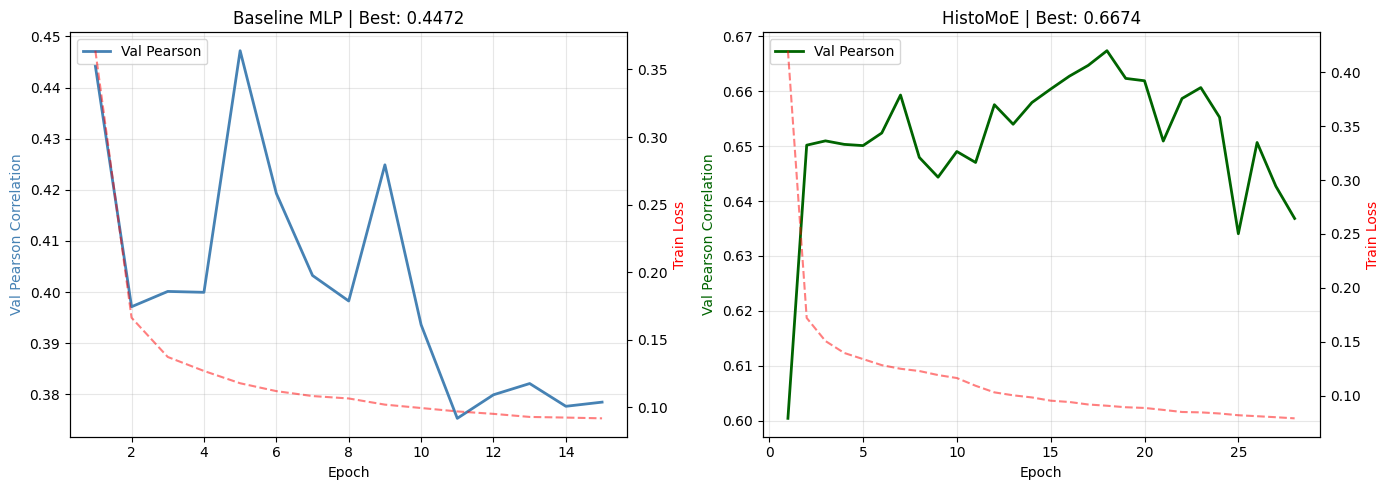

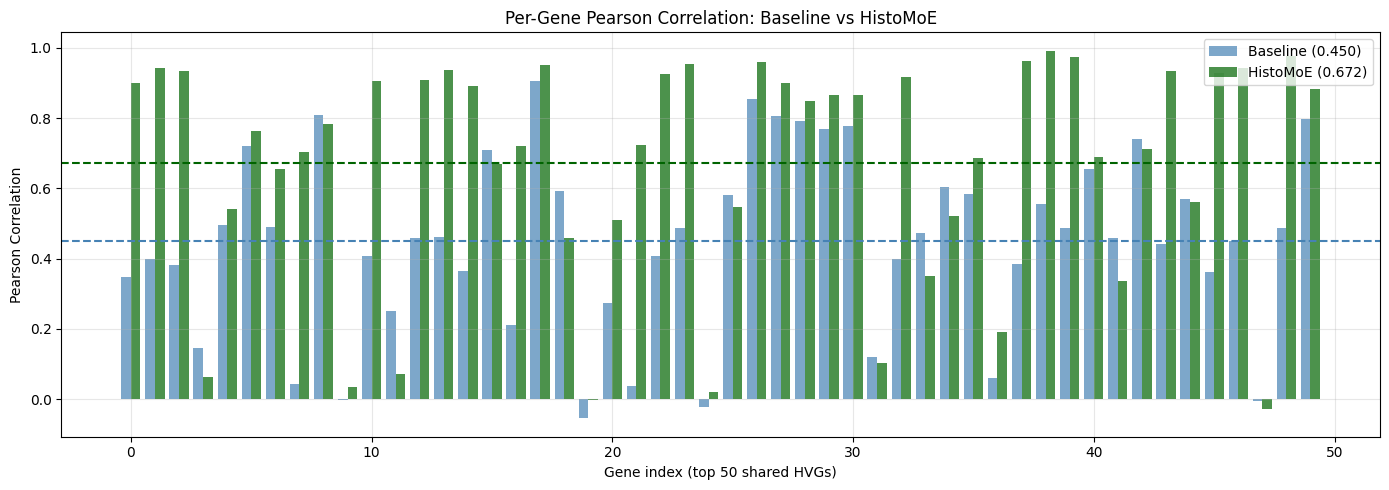

In [27]:
import matplotlib.pyplot as plt

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, label, color in zip(
    axes,
    [baseline_history, moe_history],
    ['Baseline MLP', 'HistoMoE'],
    ['steelblue', 'darkgreen']
):
    epochs = [h['epoch']       for h in hist]
    corrs  = [h['val_pearson'] for h in hist]
    losses = [h['loss']        for h in hist]
    ax2 = ax.twinx()
    ax.plot(epochs, corrs,  color=color,  linewidth=2, label='Val Pearson')
    ax2.plot(epochs, losses, color='red', linewidth=1.5, linestyle='--', alpha=0.5, label='Train Loss')
    ax.set_title(f'{label} | Best: {max(corrs):.4f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Pearson Correlation', color=color)
    ax2.set_ylabel('Train Loss', color='red')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-gene Pearson comparison ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(per_gene_baseline))
ax.bar(x - 0.2, per_gene_baseline, 0.4, label=f'Baseline ({test_corr_baseline:.3f})', alpha=0.7, color='steelblue')
ax.bar(x + 0.2, per_gene_moe,      0.4, label=f'HistoMoE ({test_corr_moe:.3f})',      alpha=0.7, color='darkgreen')
ax.axhline(test_corr_baseline, color='steelblue', linestyle='--', linewidth=1.5)
ax.axhline(test_corr_moe,      color='darkgreen', linestyle='--', linewidth=1.5)
ax.set_title('Per-Gene Pearson Correlation: Baseline vs HistoMoE')
ax.set_xlabel('Gene index (top 50 shared HVGs)')
ax.set_ylabel('Pearson Correlation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('per_gene_comparison.png', dpi=150, bbox_inches='tight')
plt.show()